In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
import pandas as pd

df = pd.read_csv("Ecommerce_Consumer_Behavior_Analysis_Data.csv")


### Data Inpection


In [8]:
df.head(3)

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            1000 non-null   object 
 1   Age                                    1000 non-null   int64  
 2   Gender                                 1000 non-null   object 
 3   Income_Level                           1000 non-null   object 
 4   Marital_Status                         1000 non-null   object 
 5   Education_Level                        1000 non-null   object 
 6   Occupation                             1000 non-null   object 
 7   Location                               1000 non-null   object 
 8   Purchase_Category                      1000 non-null   object 
 9   Purchase_Amount                        1000 non-null   object 
 10  Frequency_of_Purchase                  1000 non-null   int64  
 11  Purch

In [10]:
df.describe()

,Age,Frequency_of_Purchase,Brand_Loyalty,Product_Rating,Time_Spent_on_Product_Research(hours),Return_Rate,Customer_Satisfaction,Time_to_Decision
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.304000,6.945000,3.026000,3.033000,1.013030,0.954000,5.399000,7.547000
std,9.353238,3.147361,1.416803,1.436654,0.791802,0.810272,2.868454,4.035849
min,18.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,26.000000,4.000000,2.000000,2.000000,0.000000,0.000000,3.000000,4.000000
50%,34.500000,7.000000,3.000000,3.000000,1.000000,1.000000,5.000000,8.000000
75%,42.000000,10.000000,4.000000,4.000000,2.000000,2.000000,8.000000,11.000000
max,50.000000,12.000000,5.000000,5.000000,2.000000,2.000000,10.000000,14.000000


### Data Rearrangement

In [11]:
print(df['Purchase_Amount'].head())
print(df['Purchase_Amount'].dtype)
print(df['Purchase_Amount'].unique())

0    $333.80 
1    $222.22 
2    $426.22 
3    $101.31 
4    $211.70 
Name: Purchase_Amount, dtype: object
object
['$333.80 ' '$222.22 ' '$426.22 ' '$101.31 ' '$211.70 ' '$487.95 '
 '$486.40 ' '$218.06 ' '$201.96 ' '$418.83 ' '$389.70 ' '$238.93 '
 '$61.22 ' '$79.81 ' '$58.51 ' '$109.29 ' '$356.45 ' '$236.99 ' '$454.39 '
 '$490.75 ' '$463.07 ' '$56.74 ' '$371.32 ' '$461.00 ' '$253.37 '
 '$136.53 ' '$489.05 ' '$81.91 ' '$135.80 ' '$382.24 ' '$354.70 '
 '$433.82 ' '$282.13 ' '$454.38 ' '$138.88 ' '$52.34 ' '$338.20 '
 '$263.15 ' '$371.58 ' '$353.40 ' '$329.41 ' '$54.46 ' '$257.12 '
 '$293.04 ' '$110.40 ' '$76.27 ' '$392.08 ' '$51.22 ' '$227.57 '
 '$378.87 ' '$423.92 ' '$111.24 ' '$299.31 ' '$169.28 ' '$449.13 '
 '$427.48 ' '$171.61 ' '$240.28 ' '$310.17 ' '$166.00 ' '$362.01 '
 '$348.50 ' '$395.97 ' '$474.99 ' '$286.43 ' '$333.32 ' '$223.47 '
 '$414.83 ' '$391.38 ' '$368.40 ' '$328.36 ' '$424.39 ' '$197.12 '
 '$454.57 ' '$298.38 ' '$111.70 ' '$373.69 ' '$354.87 ' '$214.48 '
 '$399.58 ' '

In [12]:
df['Purchase_Amount'] = df['Purchase_Amount'].astype(str).str.replace('$', '', regex=False).str.strip().astype(float)
print(df['Purchase_Amount'].head())
print(df['Purchase_Amount'].dtype)

0    333.80
1    222.22
2    426.22
3    101.31
4    211.70
Name: Purchase_Amount, dtype: float64
float64


In [13]:
print(df['Social_Media_Influence'].isnull().sum())
print(df['Social_Media_Influence'].unique())

247
[nan 'Medium' 'Low' 'High']


In [14]:
mode_social_media_influence = df['Social_Media_Influence'].mode()[0]
df['Social_Media_Influence'].fillna(mode_social_media_influence, inplace=True)
print(df['Social_Media_Influence'].isnull().sum())
print(df['Social_Media_Influence'].unique())

0
['High' 'Medium' 'Low']


C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\396256015.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Social_Media_Influence'].fillna(mode_social_media_influence, inplace=True)


In [15]:
print(df['Engagement_with_Ads'].isnull().sum())
print(df['Engagement_with_Ads'].unique())

256
[nan 'High' 'Low' 'Medium']


In [16]:
mode_engagement_with_ads = df['Engagement_with_Ads'].mode()[0]
df['Engagement_with_Ads'] = df['Engagement_with_Ads'].fillna(mode_engagement_with_ads)
print(df['Engagement_with_Ads'].isnull().sum())
print(df['Engagement_with_Ads'].unique())

0
['High' 'Low' 'Medium']


In [17]:
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'])
print(df['Time_of_Purchase'].head())
print(df['Time_of_Purchase'].dtype)

0   2024-03-01
1   2024-04-16
2   2024-03-15
3   2024-10-04
4   2024-01-30
Name: Time_of_Purchase, dtype: datetime64[ns]
datetime64[ns]


In [18]:
df.duplicated().sum()

0

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Customer_ID                            1000 non-null   object        
 1   Age                                    1000 non-null   int64         
 2   Gender                                 1000 non-null   object        
 3   Income_Level                           1000 non-null   object        
 4   Marital_Status                         1000 non-null   object        
 5   Education_Level                        1000 non-null   object        
 6   Occupation                             1000 non-null   object        
 7   Location                               1000 non-null   object        
 8   Purchase_Category                      1000 non-null   object        
 9   Purchase_Amount                        1000 non-null   float64  

In [20]:
df['Time_of_Purchase']

0     2024-03-01
1     2024-04-16
2     2024-03-15
3     2024-10-04
4     2024-01-30
         ...    
995   2024-07-07
996   2024-03-28
997   2024-03-11
998   2024-03-30
999   2024-12-08
Name: Time_of_Purchase, Length: 1000, dtype: datetime64[ns]

### **Categorical vs numerical analysis**


In [21]:
df.groupby('Discount_Used')['Purchase_Amount'].mean()

Discount_Used
False    276.229436
True     273.992284
Name: Purchase_Amount, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\1108620562.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='viridis')
C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\1108620562.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Income_Level', data=df, palette='magma')
C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\1108620562.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Education_Level', data=df, palette='plasma')


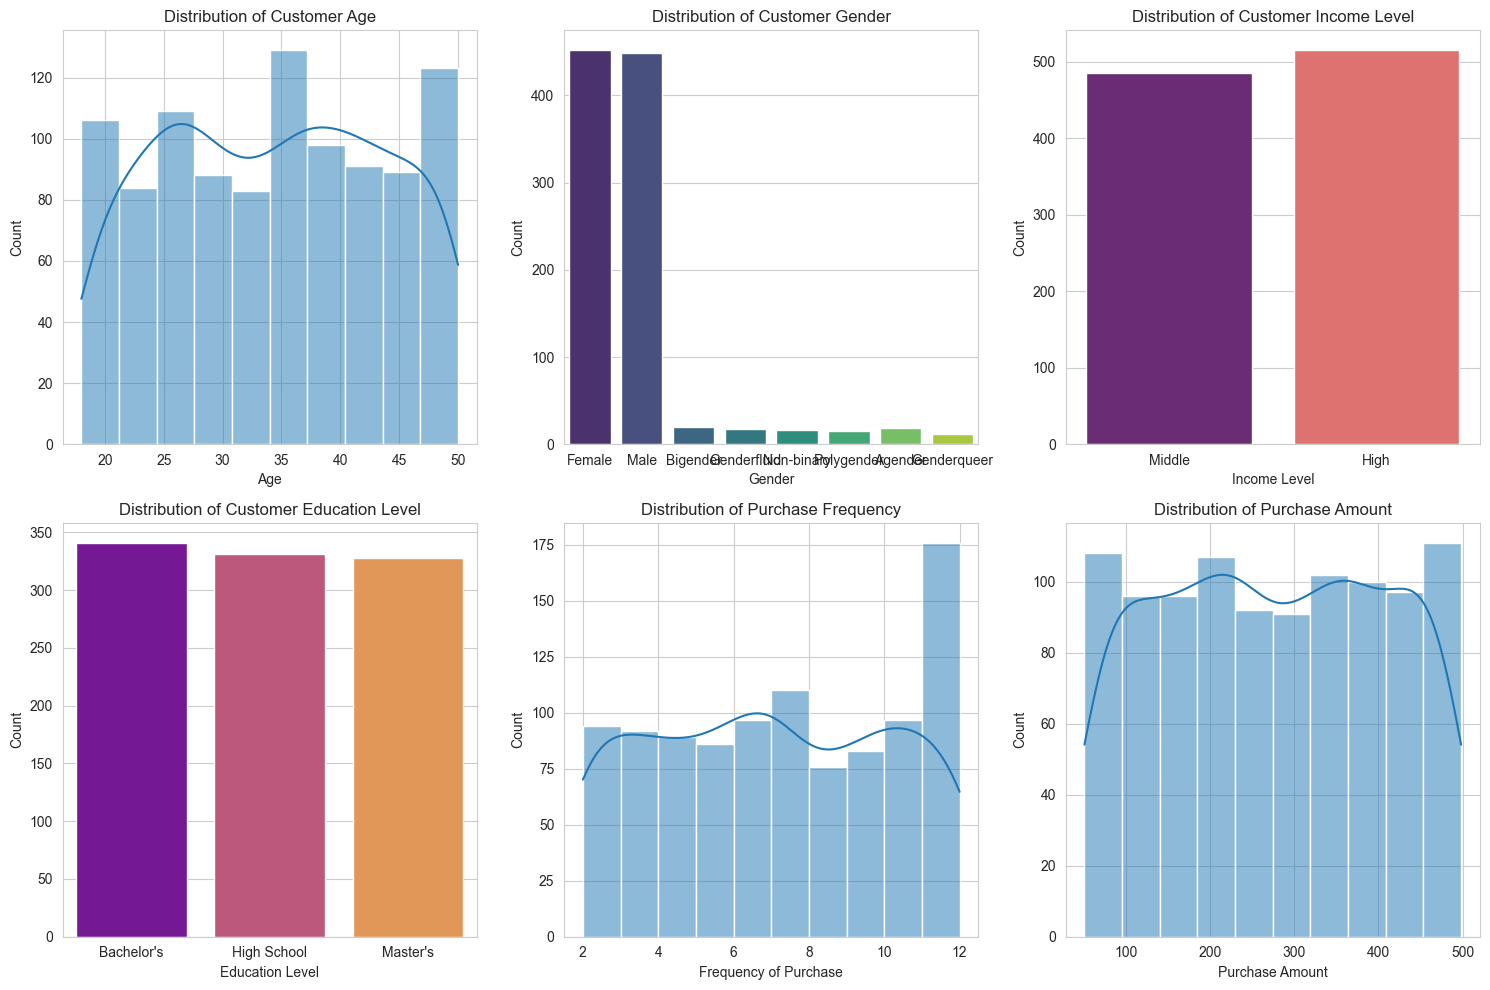

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for the plots
sns.set_style("whitegrid")

# Set up the figure size for better readability
plt.figure(figsize=(15, 10))

# 1. Distribution of 'Age'
plt.subplot(2, 3, 1)
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Count')

# 2. Distribution of 'Gender'
plt.subplot(2, 3, 2)
sns.countplot(x='Gender', data=df, palette='viridis')
plt.title('Distribution of Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# 3. Distribution of 'Income_Level'
plt.subplot(2, 3, 3)
sns.countplot(x='Income_Level', data=df, palette='magma')
plt.title('Distribution of Customer Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')

# 4. Distribution of 'Education_Level'
plt.subplot(2, 3, 4)
sns.countplot(x='Education_Level', data=df, palette='plasma')
plt.title('Distribution of Customer Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')

# 5. Distribution of 'Frequency_of_Purchase'
plt.subplot(2, 3, 5)
sns.histplot(df['Frequency_of_Purchase'], bins=10, kde=True)
plt.title('Distribution of Purchase Frequency')
plt.xlabel('Frequency of Purchase')
plt.ylabel('Count')

# 6. Distribution of 'Purchase_Amount'
plt.subplot(2, 3, 6)
sns.histplot(df['Purchase_Amount'], bins=10, kde=True)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\3694358392.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Income_Level', y='Purchase_Amount', data=df, palette='viridis', ci=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\3694358392.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Income_Level', y='Purchase_Amount', data=df, palette='viridis', ci=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\3694358392.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Education_Level', y='Purchase_Amount', data=df, palette='magma', ci=None)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\3694358392.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

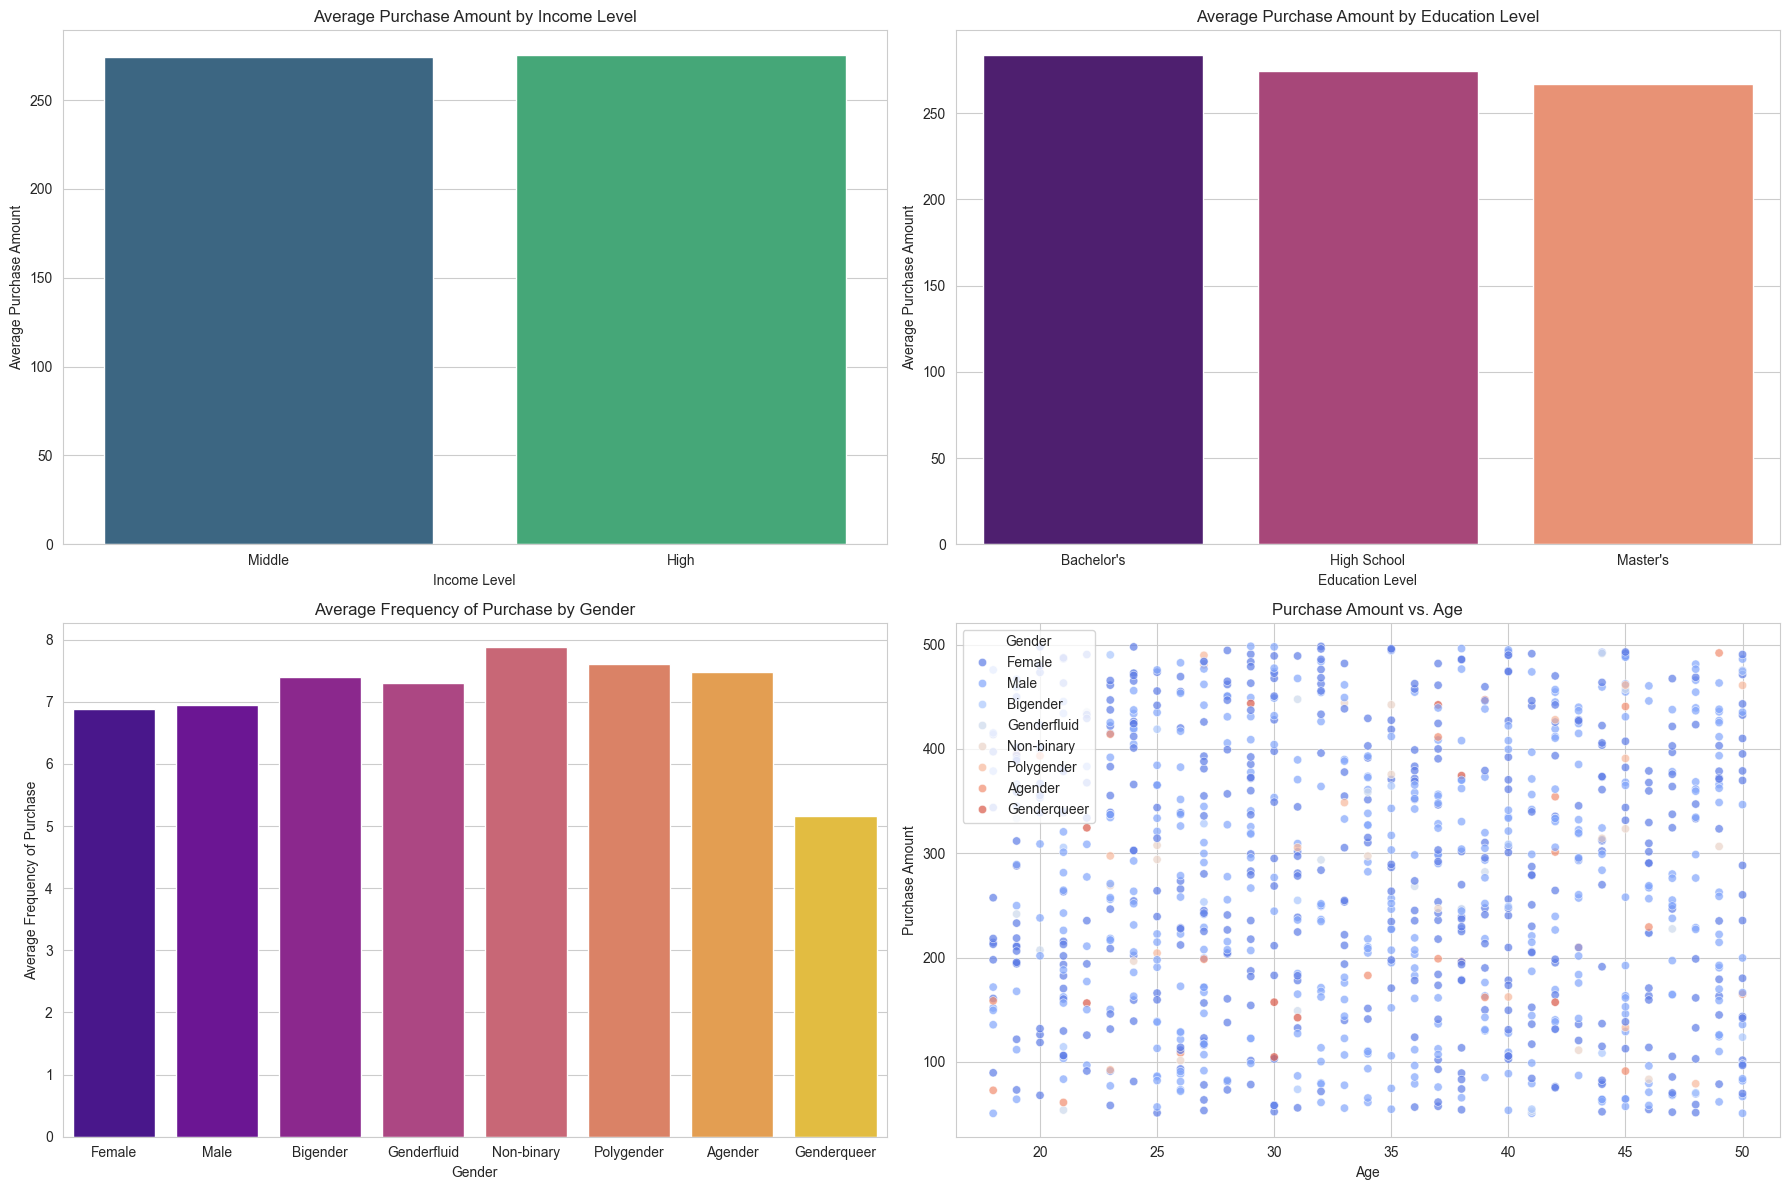

In [23]:


sns.set_style("whitegrid")

plt.figure(figsize=(18, 12))

# 1. Average Purchase Amount by Income Level
plt.subplot(2, 2, 1)
sns.barplot(x='Income_Level', y='Purchase_Amount', data=df, palette='viridis', ci=None)
plt.title('Average Purchase Amount by Income Level')
plt.xlabel('Income Level')
plt.ylabel('Average Purchase Amount')

# 2. Average Purchase Amount by Education Level
plt.subplot(2, 2, 2)
sns.barplot(x='Education_Level', y='Purchase_Amount', data=df, palette='magma', ci=None)
plt.title('Average Purchase Amount by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Purchase Amount')

# 3. Average Frequency of Purchase by Gender
plt.subplot(2, 2, 3)
sns.barplot(x='Gender', y='Frequency_of_Purchase', data=df, palette='plasma', ci=None)
plt.title('Average Frequency of Purchase by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Frequency of Purchase')

# 4. Purchase Amount vs. Age (Scatter Plot)
plt.subplot(2, 2, 4)
sns.scatterplot(x='Age', y='Purchase_Amount', data=df, hue='Gender', palette='coolwarm', alpha=0.7)
plt.title('Purchase Amount vs. Age')
plt.xlabel('Age')
plt.ylabel('Purchase Amount')
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

In [24]:
df['Gender'].unique()

array(['Female', 'Male', 'Bigender', 'Genderfluid', 'Non-binary',
       'Polygender', 'Agender', 'Genderqueer'], dtype=object)

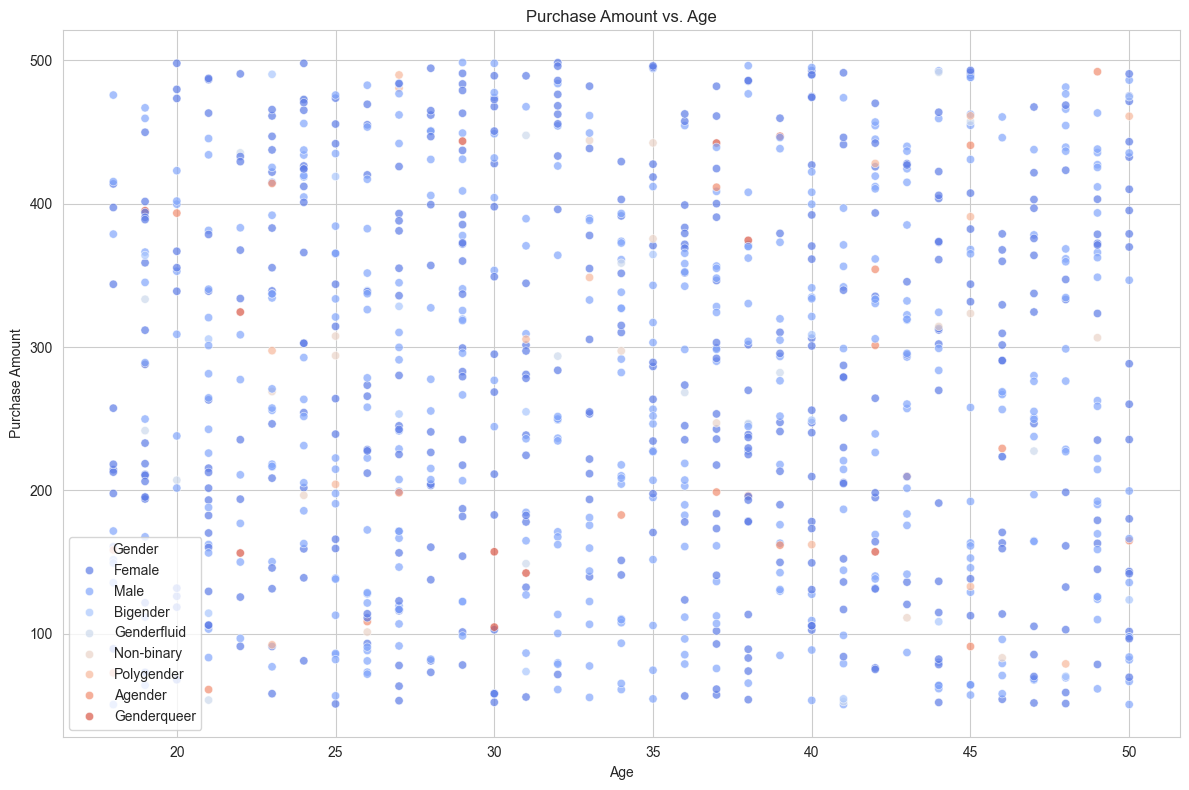

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 4. Purchase Amount vs. Age (Scatter Plot)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Age', y='Purchase_Amount', data=df, hue='Gender', palette='coolwarm', alpha=0.7)
plt.title('Purchase Amount vs. Age')
plt.xlabel('Age')
plt.ylabel('Purchase Amount')
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

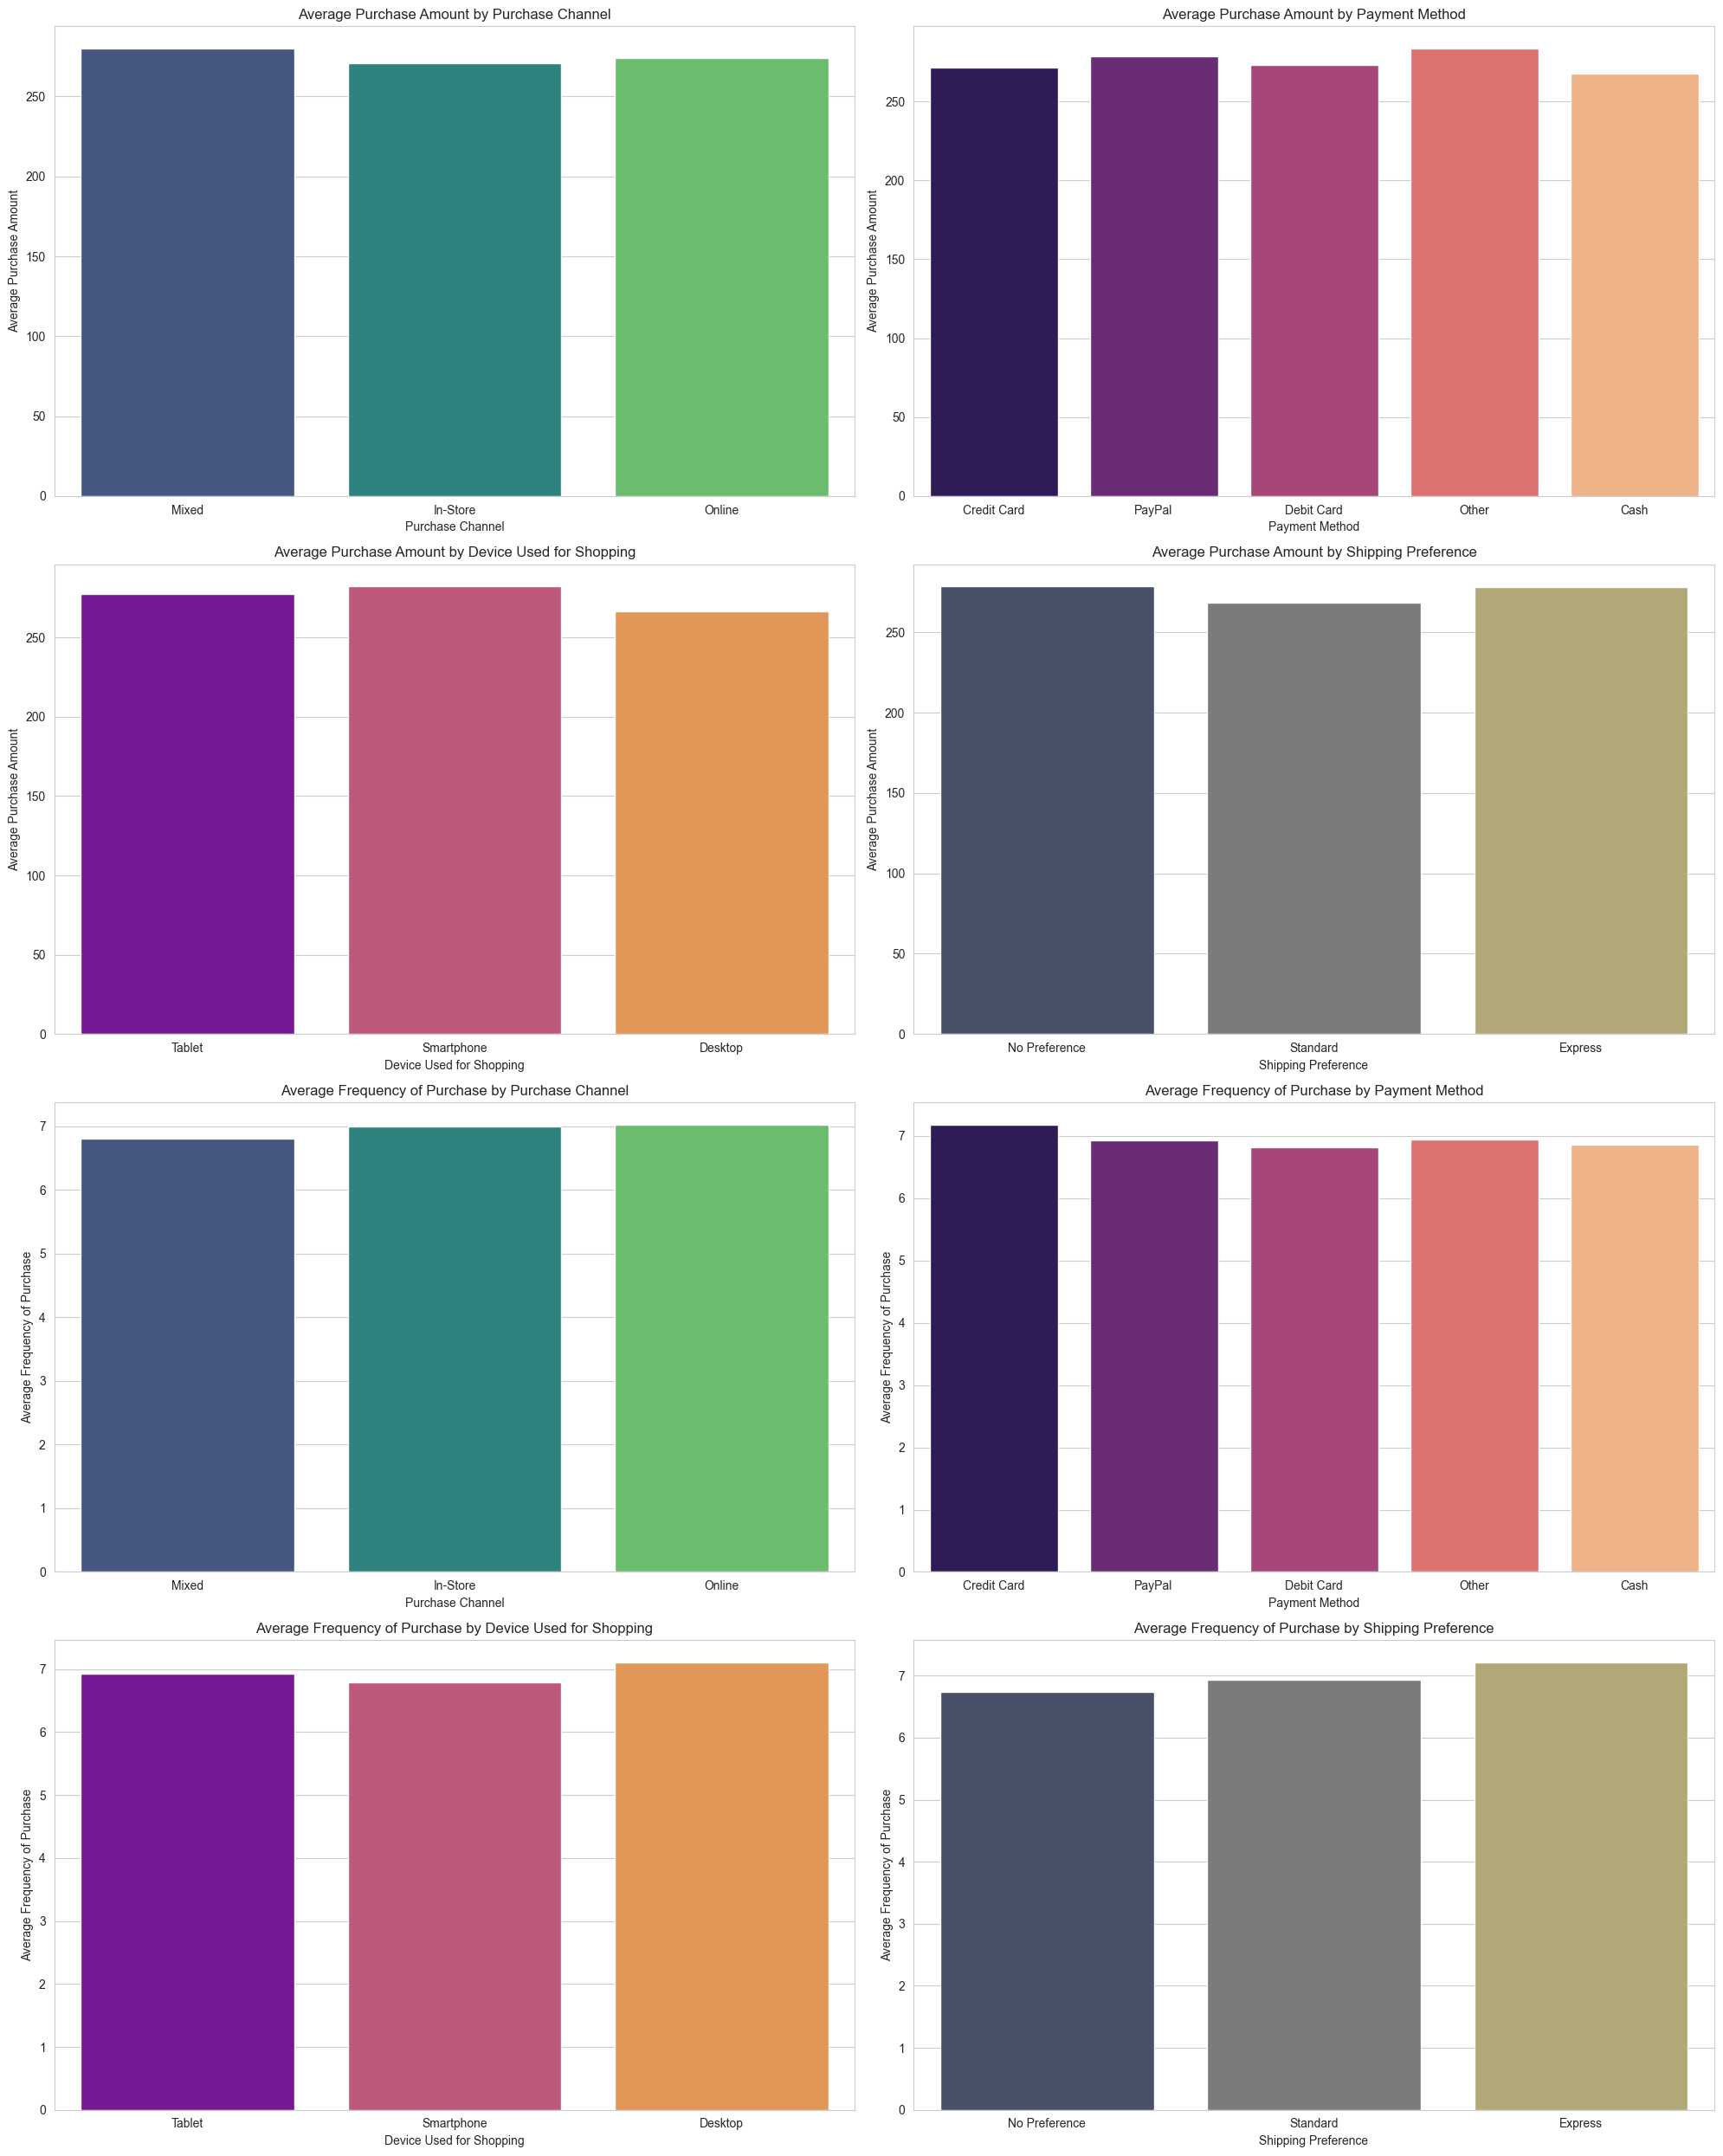

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a figure to hold all plots
plt.figure(figsize=(20, 25))

# --- Average Purchase Amount Analysis ---

# 1. Average Purchase Amount by Purchase Channel
plt.subplot(4, 2, 1)
sns.barplot(x='Purchase_Channel', y='Purchase_Amount', data=df, palette='viridis', errorbar=None, hue='Purchase_Channel', legend=False)
plt.title('Average Purchase Amount by Purchase Channel')
plt.xlabel('Purchase Channel')
plt.ylabel('Average Purchase Amount')

# 2. Average Purchase Amount by Payment Method
plt.subplot(4, 2, 2)
sns.barplot(x='Payment_Method', y='Purchase_Amount', data=df, palette='magma', errorbar=None, hue='Payment_Method', legend=False)
plt.title('Average Purchase Amount by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Purchase Amount')

# 3. Average Purchase Amount by Device Used for Shopping
plt.subplot(4, 2, 3)
sns.barplot(x='Device_Used_for_Shopping', y='Purchase_Amount', data=df, palette='plasma', errorbar=None, hue='Device_Used_for_Shopping', legend=False)
plt.title('Average Purchase Amount by Device Used for Shopping')
plt.xlabel('Device Used for Shopping')
plt.ylabel('Average Purchase Amount')

# 4. Average Purchase Amount by Shipping Preference
plt.subplot(4, 2, 4)
sns.barplot(x='Shipping_Preference', y='Purchase_Amount', data=df, palette='cividis', errorbar=None, hue='Shipping_Preference', legend=False)
plt.title('Average Purchase Amount by Shipping Preference')
plt.xlabel('Shipping Preference')
plt.ylabel('Average Purchase Amount')

# --- Average Frequency of Purchase Analysis ---

# 5. Average Frequency of Purchase by Purchase Channel
plt.subplot(4, 2, 5)
sns.barplot(x='Purchase_Channel', y='Frequency_of_Purchase', data=df, palette='viridis', errorbar=None, hue='Purchase_Channel', legend=False)
plt.title('Average Frequency of Purchase by Purchase Channel')
plt.xlabel('Purchase Channel')
plt.ylabel('Average Frequency of Purchase')

# 6. Average Frequency of Purchase by Payment Method
plt.subplot(4, 2, 6)
sns.barplot(x='Payment_Method', y='Frequency_of_Purchase', data=df, palette='magma', errorbar=None, hue='Payment_Method', legend=False)
plt.title('Average Frequency of Purchase by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Frequency of Purchase')

# 7. Average Frequency of Purchase by Device Used for Shopping
plt.subplot(4, 2, 7)
sns.barplot(x='Device_Used_for_Shopping', y='Frequency_of_Purchase', data=df, palette='plasma', errorbar=None, hue='Device_Used_for_Shopping', legend=False)
plt.title('Average Frequency of Purchase by Device Used for Shopping')
plt.xlabel('Device Used for Shopping')
plt.ylabel('Average Frequency of Purchase')

# 8. Average Frequency of Purchase by Shipping Preference
plt.subplot(4, 2, 8)
sns.barplot(x='Shipping_Preference', y='Frequency_of_Purchase', data=df, palette='cividis', errorbar=None, hue='Shipping_Preference', legend=False)
plt.title('Average Frequency of Purchase by Shipping Preference')
plt.xlabel('Shipping Preference')
plt.ylabel('Average Frequency of Purchase')

plt.tight_layout()
plt.show()

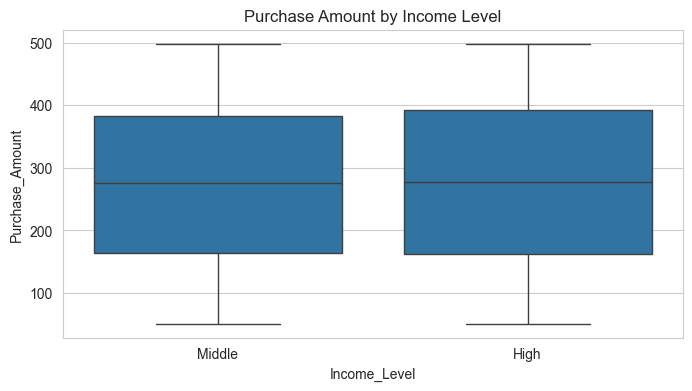

In [27]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Income_Level', y='Purchase_Amount', data=df)
plt.title("Purchase Amount by Income Level")
plt.show()

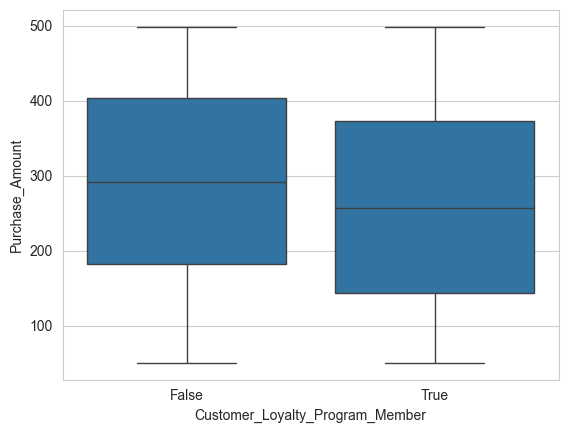

In [28]:
df.groupby('Customer_Loyalty_Program_Member')['Purchase_Amount'].mean()
sns.boxplot(
    x='Customer_Loyalty_Program_Member',
    y='Purchase_Amount',
    data=df
)
plt.show()

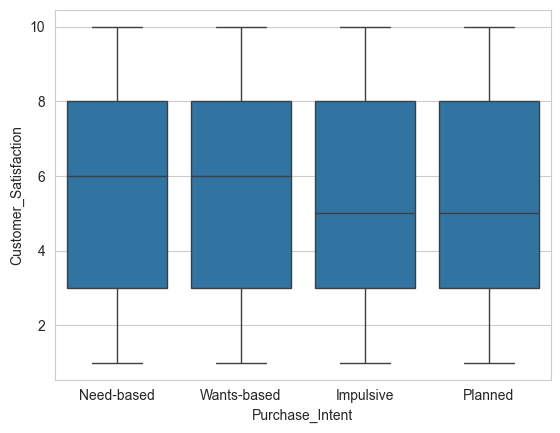

In [29]:
sns.boxplot(
    x='Purchase_Intent',
    y='Customer_Satisfaction',
    data=df
)
plt.show()

In [30]:
df['spend_segment'] = pd.qcut(
    df['Purchase_Amount'],
    q=4,
    labels=['Low Spenders', 'Mid-Low', 'Mid-High', 'High Spenders']
)

In [31]:
df.groupby('spend_segment')['Purchase_Amount'].agg(
    count='count',
    mean='mean',
    median='median'
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16088\5479380.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('spend_segment')['Purchase_Amount'].agg(


,count,mean,median
spend_segment,,,
Low Spenders,250,104.15400,104.070
Mid-Low,250,217.38236,217.230
Mid-High,250,333.03792,334.335
High Spenders,250,445.68124,445.980


In [32]:
df.groupby('Time_to_Decision').agg(
    avg_spend=('Purchase_Amount', 'mean'),
    avg_satisfaction=('Customer_Satisfaction', 'mean')
)


,avg_spend,avg_satisfaction
Time_to_Decision,,
1,266.206860,5.674419
2,286.416875,5.687500
3,287.880000,5.580247
4,248.851385,4.630769
5,272.719322,5.389831
6,266.527500,5.708333
7,291.649881,5.976190
8,260.392651,4.542169
9,291.516379,5.068966


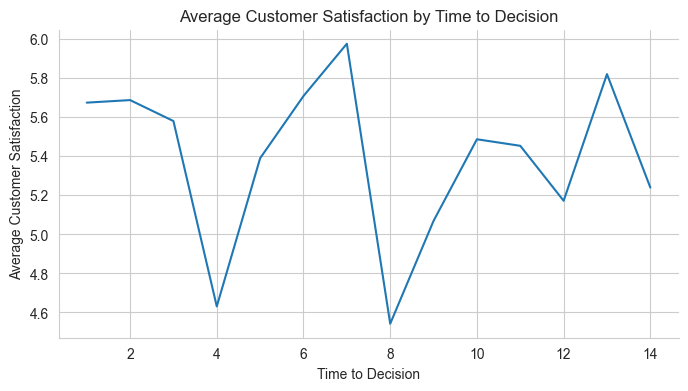

In [33]:
from matplotlib import pyplot as plt

# Re-create the DataFrame with avg_spend and avg_satisfaction
time_to_decision_data = df.groupby('Time_to_Decision').agg(
    avg_spend=('Purchase_Amount', 'mean'),
    avg_satisfaction=('Customer_Satisfaction', 'mean')
)

time_to_decision_data['avg_satisfaction'].plot(kind='line', figsize=(8, 4), title='Average Customer Satisfaction by Time to Decision')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.xlabel('Time to Decision')
plt.ylabel('Average Customer Satisfaction')
plt.show()

In [34]:
segment_profile = df.groupby('Customer_Loyalty_Program_Member').agg(
    avg_spend=('Purchase_Amount', 'mean'),
    avg_rating=('Product_Rating', 'mean'),
    avg_satisfaction=('Customer_Satisfaction', 'mean'),
    discount_rate=('Discount_Used', 'mean')
)

segment_profile

,avg_spend,avg_rating,avg_satisfaction,discount_rate
Customer_Loyalty_Program_Member,,,,
False,288.373026,3.037328,5.312377,0.497053
True,261.266823,3.028513,5.488798,0.545825


In [35]:
df.groupby('Return_Rate')['Product_Rating'].mean()

Return_Rate
0    2.897727
1    3.125731
2    3.084967
Name: Product_Rating, dtype: float64

Heading - Explain

Content - 4 5 lines

sources - Data Kaggle link

Code - link

CTA - Selling Poit

Images 2 3

In [37]:
most_sold_by_time = df.groupby('Time_of_Purchase')['Purchase_Category'].agg(pd.Series.mode)

print(most_sold_by_time)

Time_of_Purchase
2024-01-01                                        Arts & Crafts
2024-01-02    [Beauty & Personal Care, Gardening & Outdoors,...
2024-01-03                                          Health Care
2024-01-04                                      Office Supplies
2024-01-05                     [Arts & Crafts, Home Appliances]
                                    ...                        
2024-12-26                                               Hotels
2024-12-27        [Electronics, Health Care, Sports & Outdoors]
2024-12-28                                         Luxury Goods
2024-12-29                                            Groceries
2024-12-30                                   Health Supplements
Name: Purchase_Category, Length: 344, dtype: object


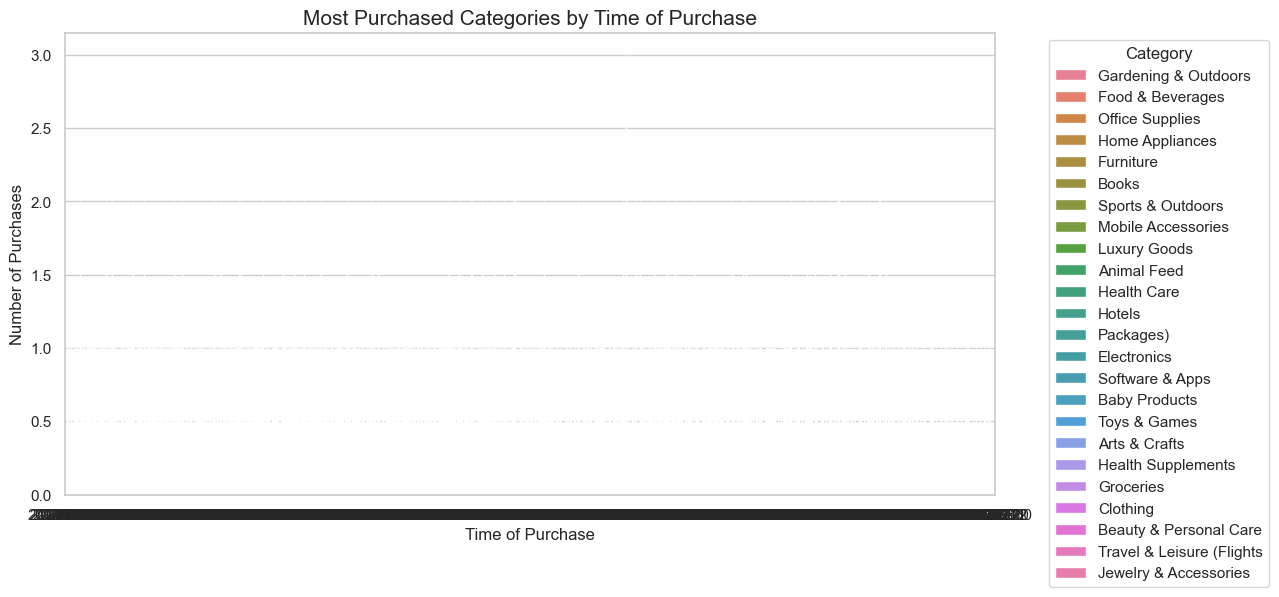

In [40]:
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Time_of_Purchase', hue='Purchase_Category')

# Customize the chart
plt.title('Most Purchased Categories by Time of Purchase', fontsize=15)
plt.xlabel('Time of Purchase', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')


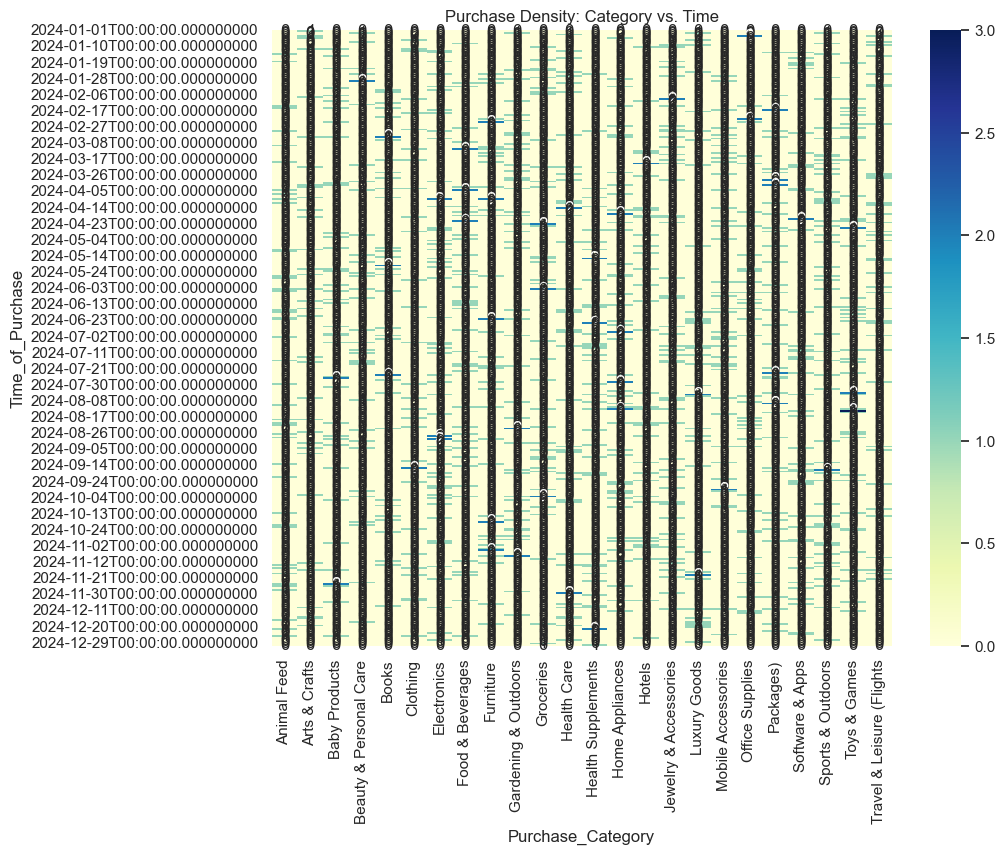

In [41]:
pivot_df = df.groupby(['Time_of_Purchase', 'Purchase_Category']).size().unstack(fill_value=0)

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Purchase Density: Category vs. Time')
plt.show()

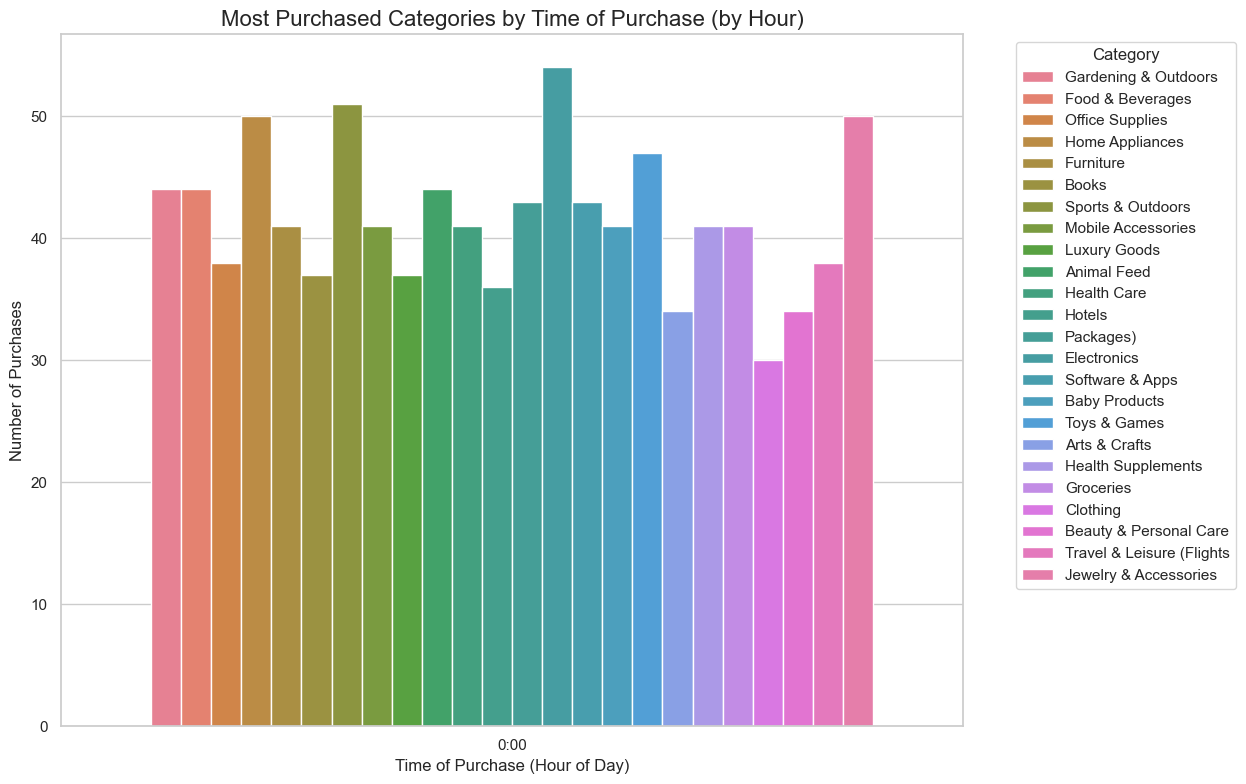

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Data Preparation (Essential for Time-based Analysis) ---

# Convert the 'Time_of_Purchase' column to a datetime object
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'])

# Extract just the hour of purchase into a new column
# This groups purchases meaningfully (e.g., 9 AM vs. 10 AM)
df['Purchase_Hour'] = df['Time_of_Purchase'].dt.hour.astype(str) + ':00'

# Ensure the 'Purchase_Amount' is numeric if you wanted to plot total sales value instead of count
# df['Purchase_Amount'] = pd.to_numeric(df['Purchase_Amount'].str.replace('[$,]', '', regex=True))


# --- 2. Create the Functional Grouped Bar Chart ---

# Set a nice visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 8)) # Make the figure wider to fit all categories clearly

# Use seaborn's countplot which automatically counts occurrences of categories
# X-axis is the hour, HUE separates bars by category
sns.countplot(
    data=df, 
    x='Purchase_Hour', 
    hue='Purchase_Category', 
    # Use order to sort hours correctly on the X-axis if needed
    # order=sorted(df['Purchase_Hour'].unique()) 
)

# --- 3. Customize and Display the Chart ---

plt.title('Most Purchased Categories by Time of Purchase (by Hour)', fontsize=16)
plt.xlabel('Time of Purchase (Hour of Day)', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)

# Move the legend outside the plot area so it doesn't overlap with bars
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to prevent labels from being cut off
plt.tight_layout(rect=[0, 0, 0.85, 1]) 

# Display the visualization
plt.show()
